<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-XLA/blob/main/B%E1%BA%A3n_sao_c%E1%BB%A7a_BVU_CaoHoc_BuiVanHuan_XLA_BaiTap_12_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Liên kết github: https://github.com/huanbv/BVU.CaoHoc.BuiVanHuan-XLA

**Bài tập 1 - Ngày 12/07/2026**

a) Cho tập kết nối 𝑉 = { 0 , 1 } , tìm tất cả các đường dẫn kết nối 4, 8, m ngắn nhất đi từ 𝑝 đến 𝑞 .

Kết nối 4: chỉ đi lên, xuống, trái, phải. Đường đi ngắn nhất từ 𝑝 đến 𝑞 có độ dài bằng khoảng cách Manhattan.

Kết nối 8: cho phép đi chéo, nên đường đi ngắn nhất có độ dài bằng khoảng cách Chessboard.

Kết nối m: nếu định nghĩa là “mọi hướng”, thì có thể đi thẳng từ 𝑝 đến 𝑞 trong một bước duy nhất.

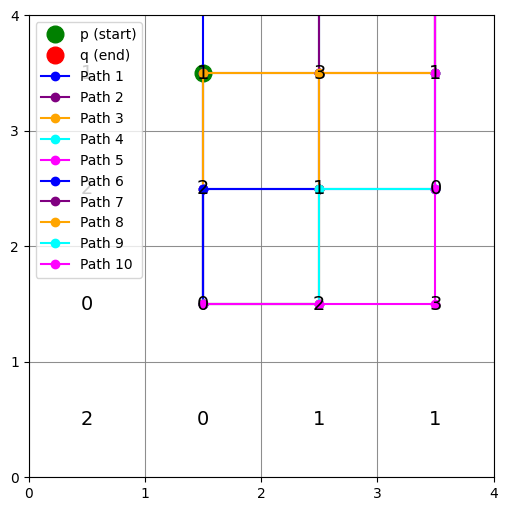

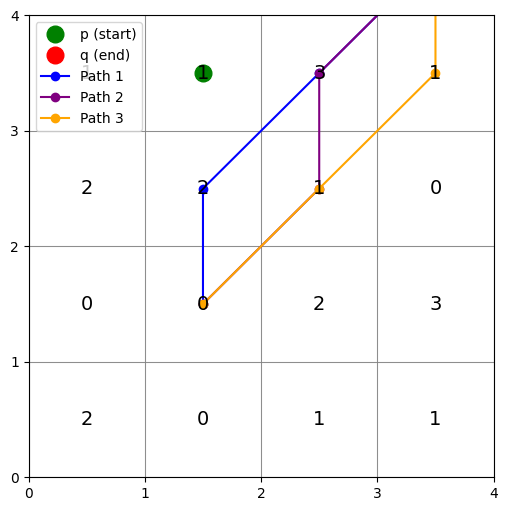

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Ma trận số liệu (ví dụ từ ảnh)
grid = np.array([
    [2, 0, 1, 1],
    [0, 0, 2, 3],
    [2, 2, 1, 0],
    [1, 1, 3, 1]
])

def draw_paths_with_numbers(paths, grid, start=(0,0), end=(3,3)):
    n, m = grid.shape
    fig, ax = plt.subplots(figsize=(6,6))

    # Vẽ lưới
    for x in range(n+1):
        ax.axhline(x, color='gray', linewidth=0.5)
        ax.axvline(x, color='gray', linewidth=0.5)

    # Đánh số trong từng ô
    for i in range(n):
        for j in range(m):
            ax.text(j+0.5, i+0.5, str(grid[i,j]),
                    ha='center', va='center', fontsize=14)

    # Vẽ điểm start và end
    ax.plot(start[1]+0.5, start[0]+0.5, 'go', markersize=12, label="p (start)")
    ax.plot(end[1]+0.5, end[0]+0.5, 'ro', markersize=12, label="q (end)")

    # Vẽ từng đường đi
    colors = ['blue','purple','orange','cyan','magenta']
    for i, path in enumerate(paths):
        xs = [y+0.5 for x,y in path]
        ys = [x+0.5 for x,y in path]
        ax.plot(xs, ys, marker='o', color=colors[i % len(colors)], label=f'Path {i+1}')

    ax.set_xlim(0, m)
    ax.set_ylim(0, n)
    ax.set_xticks(range(m+1))
    ax.set_yticks(range(n+1))
    ax.grid(True)
    ax.legend()
    plt.show()

# Ví dụ: vẽ các đường đi ngắn nhất theo kết nối 4
draw_paths_with_numbers(paths_4, grid, start=p, end=q)

# Ví dụ: vẽ các đường đi ngắn nhất theo kết nối 8
draw_paths_with_numbers(paths_8, grid, start=p, end=q)


b) Cho tập kết nối 𝑉 = { 0 , 1 , 2 } , tìm tất cả các đường dẫn kết nối 4, 8, m ngắn nhất đi từ 𝑝 đến 𝑞 .

Cho phép bước nhảy 2 đơn vị, nên số bước đi ngắn nhất giảm xuống.

Kết nối 4: có thể kết hợp bước 1 và bước 2 để đến 𝑞 , số đường đi ngắn nhất nhiều hơn.

Kết nối 8: có thể đi chéo hoặc nhảy xa, số bước ít hơn và nhiều cách đi hơn.

Kết nối m: nếu cho phép đi mọi hướng, có thể đi thẳng từ 𝑝 đến 𝑞 bằng một bước duy nhất (nếu bước nhảy phù hợp).

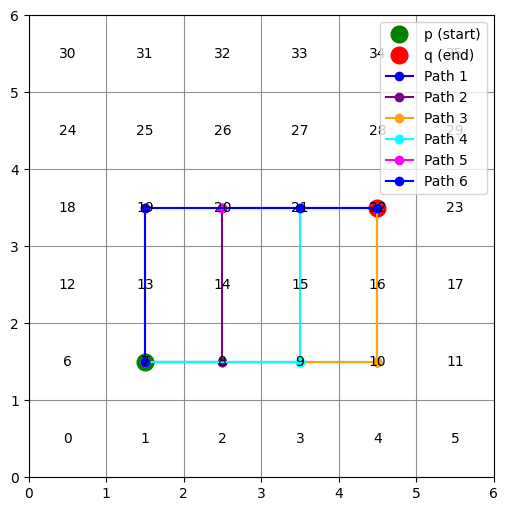

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

# Tọa độ p và q
p = (1, 1)
q = (4, 3)

# Kết nối 4 + bước nhảy 2
moves_V = [(1,0), (-1,0), (0,1), (0,-1),
           (2,0), (-2,0), (0,2), (0,-2)]

def bfs(start, end, moves, n=6, m=6):
    queue = deque([[start]])
    visited = {start:0}
    paths = []
    min_len = None

    while queue:
        path = queue.popleft()
        x,y = path[-1]

        if (x,y) == end:
            if min_len is None:
                min_len = len(path)
            if len(path) == min_len:
                paths.append(path)
            continue

        for dx,dy in moves:
            nx, ny = x+dx, y+dy
            if 0 <= nx < n and 0 <= ny < m:
                if (nx,ny) not in visited or visited[(nx,ny)] >= len(path)+1:
                    visited[(nx,ny)] = len(path)+1
                    queue.append(path+[(nx,ny)])
    return paths

paths_V = bfs(p, q, moves_V)

# Ma trận số liệu minh họa (có thể thay bằng dữ liệu thực tế)
grid = np.arange(36).reshape(6,6)

def draw_paths_with_numbers(paths, grid, start, end):
    n, m = grid.shape
    fig, ax = plt.subplots(figsize=(6,6))

    # Vẽ lưới
    for x in range(n+1):
        ax.axhline(x, color='gray', linewidth=0.5)
        ax.axvline(x, color='gray', linewidth=0.5)

    # Đánh số trong từng ô
    for i in range(n):
        for j in range(m):
            ax.text(j+0.5, i+0.5, str(grid[i,j]),
                    ha='center', va='center', fontsize=10)

    # Vẽ điểm start và end
    ax.plot(start[0]+0.5, start[1]+0.5, 'go', markersize=12, label="p (start)")
    ax.plot(end[0]+0.5, end[1]+0.5, 'ro', markersize=12, label="q (end)")

    # Vẽ từng đường đi
    colors = ['blue','purple','orange','cyan','magenta']
    for i, path in enumerate(paths):
        xs = [x+0.5 for x,y in path]
        ys = [y+0.5 for x,y in path]
        ax.plot(xs, ys, marker='o', color=colors[i % len(colors)], label=f'Path {i+1}')

    ax.set_xlim(0, m)
    ax.set_ylim(0, n)
    ax.set_xticks(range(m+1))
    ax.set_yticks(range(n+1))
    ax.grid(True)
    ax.legend()
    plt.show()

# Vẽ các đường đi ngắn nhất theo V={0,1,2}
draw_paths_with_numbers(paths_V, grid, start=p, end=q)


c) Tính khoảng cách Euclide, City block và Chessboard giữa hai điểm 𝑝 và 𝑞 .

Euclidean: 3.605551275463989
City block: 5
Chessboard: 3


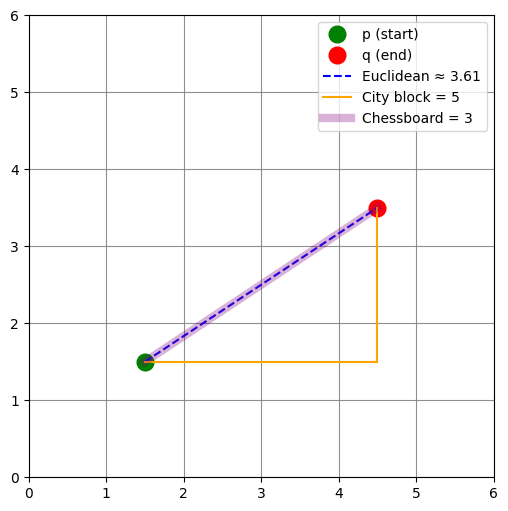

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Tọa độ p và q
p = (1, 1)
q = (4, 3)

# Tính khoảng cách
d_euclid = np.sqrt((p[0]-q[0])**2 + (p[1]-q[1])**2)
d_city = abs(p[0]-q[0]) + abs(p[1]-q[1])
d_chess = max(abs(p[0]-q[0]), abs(p[1]-q[1]))

print("Euclidean:", d_euclid)
print("City block:", d_city)
print("Chessboard:", d_chess)

# Vẽ minh họa
fig, ax = plt.subplots(figsize=(6,6))

# Vẽ lưới
for x in range(6):
    ax.axhline(x, color='gray', linewidth=0.5)
    ax.axvline(x, color='gray', linewidth=0.5)

# Vẽ điểm p và q
ax.plot(p[0]+0.5, p[1]+0.5, 'go', markersize=12, label="p (start)")
ax.plot(q[0]+0.5, q[1]+0.5, 'ro', markersize=12, label="q (end)")

# Vẽ khoảng cách Euclidean (đường thẳng)
ax.plot([p[0]+0.5, q[0]+0.5], [p[1]+0.5, q[1]+0.5], 'b--', label=f"Euclidean ≈ {d_euclid:.2f}")

# Vẽ khoảng cách City block (đi theo trục)
ax.plot([p[0]+0.5, q[0]+0.5], [p[1]+0.5, p[1]+0.5], 'orange')
ax.plot([q[0]+0.5, q[0]+0.5], [p[1]+0.5, q[1]+0.5], 'orange', label=f"City block = {d_city}")

# Vẽ khoảng cách Chessboard (theo max dx,dy)
ax.plot([p[0]+0.5, q[0]+0.5], [p[1]+0.5, q[1]+0.5], 'purple', alpha=0.3, linewidth=6, label=f"Chessboard = {d_chess}")

ax.set_xlim(0,6)
ax.set_ylim(0,6)
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.grid(True)
ax.legend()
plt.show()


Giả sử hai điểm 𝑝 = ( 𝑥 𝑝 , 𝑦 𝑝 ) , 𝑞 = ( 𝑥 𝑞 , 𝑦 𝑞 ) , ta có ba loại khoảng cách:

Euclidean (Euclide): 𝑑 𝐸 = ( 𝑥 𝑝 − 𝑥 𝑞 ) 2 + ( 𝑦 𝑝 − 𝑦 𝑞 ) 2

City block (Manhattan): 𝑑 𝑀 = ∣ 𝑥 𝑝 − 𝑥 𝑞 ∣ + ∣ 𝑦 𝑝 − 𝑦 𝑞 ∣

Chessboard (Chebyshev): 𝑑 𝐶 = max ⁡ ( ∣ 𝑥 𝑝 − 𝑥 𝑞 ∣ , ∣ 𝑦 𝑝 − 𝑦 𝑞 ∣ )

Ví dụ với 𝑝 = ( 1 , 1 ) , 𝑞 = ( 4 , 3 ) :

𝑑𝐸=13≈3.61

𝑑𝑀=5

𝑑𝐶=3

d) Trường hợp tổng quát, khoảng cách nào trong các khoảng cách Euclide, City block và Chessboard là nhỏ nhất.

Có bất đẳng thức chuẩn: 𝑑 𝐶 ≤ 𝑑 𝐸 ≤ 𝑑 𝑀

*   Chessboard luôn nhỏ nhất, vì nó chỉ lấy giá trị lớn hơn trong hai khoảng cách theo trục.
*   Euclidean nằm giữa, vì nó tính theo định lý Pythagoras.
*   City block luôn lớn nhất, vì nó cộng cả hai khoảng cách theo trục.



p=(1, 1), q=(4, 3)
Chessboard: 3, Euclidean: 3.61, City block: 5
Kiểm chứng: 3 <= 3.61 <= 5



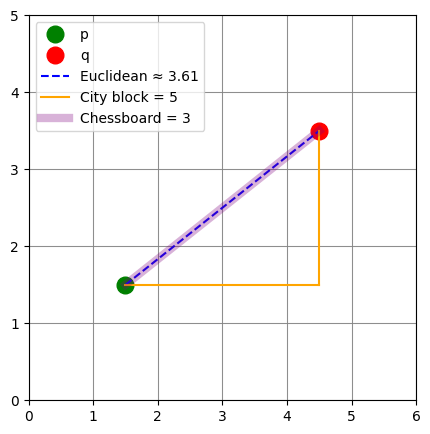

p=(0, 0), q=(5, 0)
Chessboard: 5, Euclidean: 5.00, City block: 5
Kiểm chứng: 5 <= 5.00 <= 5



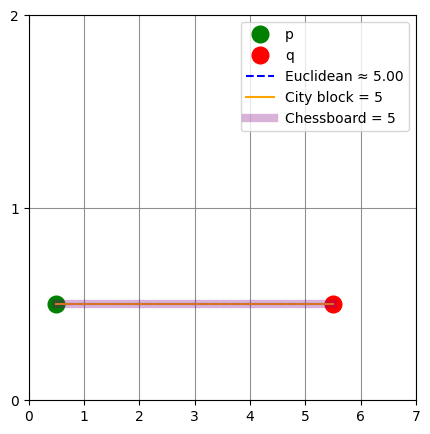

p=(2, 2), q=(2, 7)
Chessboard: 5, Euclidean: 5.00, City block: 5
Kiểm chứng: 5 <= 5.00 <= 5



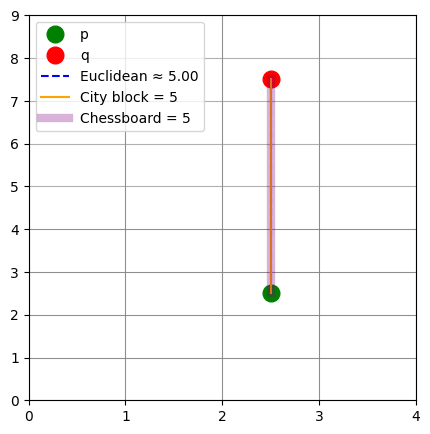

p=(3, 1), q=(6, 5)
Chessboard: 4, Euclidean: 5.00, City block: 7
Kiểm chứng: 4 <= 5.00 <= 7



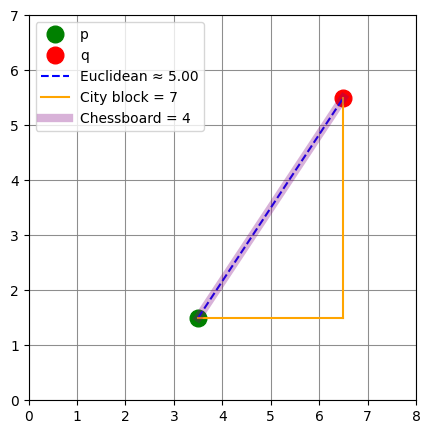

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def distances(p, q):
    dx = abs(p[0]-q[0])
    dy = abs(p[1]-q[1])
    d_euclid = np.sqrt(dx**2 + dy**2)
    d_city = dx + dy
    d_chess = max(dx, dy)
    return d_chess, d_euclid, d_city

# Một vài cặp điểm để kiểm chứng
points = [((1,1),(4,3)), ((0,0),(5,0)), ((2,2),(2,7)), ((3,1),(6,5))]

for p,q in points:
    dC, dE, dM = distances(p,q)
    print(f"p={p}, q={q}")
    print(f"Chessboard: {dC}, Euclidean: {dE:.2f}, City block: {dM}")
    print(f"Kiểm chứng: {dC} <= {dE:.2f} <= {dM}\n")

    # Vẽ minh họa cho từng cặp điểm
    fig, ax = plt.subplots(figsize=(5,5))
    max_x = max(p[0], q[0]) + 2
    max_y = max(p[1], q[1]) + 2

    # Vẽ lưới
    for x in range(max_x+1):
        ax.axhline(x, color='gray', linewidth=0.5)
        ax.axvline(x, color='gray', linewidth=0.5)

    # Vẽ điểm p và q
    ax.plot(p[0]+0.5, p[1]+0.5, 'go', markersize=12, label="p")
    ax.plot(q[0]+0.5, q[1]+0.5, 'ro', markersize=12, label="q")

    # Euclidean (đường thẳng)
    ax.plot([p[0]+0.5, q[0]+0.5], [p[1]+0.5, q[1]+0.5], 'b--', label=f"Euclidean ≈ {dE:.2f}")

    # City block (đi theo trục)
    ax.plot([p[0]+0.5, q[0]+0.5], [p[1]+0.5, p[1]+0.5], 'orange')
    ax.plot([q[0]+0.5, q[0]+0.5], [p[1]+0.5, q[1]+0.5], 'orange', label=f"City block = {dM}")

    # Chessboard (theo max dx,dy)
    ax.plot([p[0]+0.5, q[0]+0.5], [p[1]+0.5, q[1]+0.5], 'purple', alpha=0.3, linewidth=6, label=f"Chessboard = {dC}")

    ax.set_xlim(0, max_x)
    ax.set_ylim(0, max_y)
    ax.set_xticks(range(max_x+1))
    ax.set_yticks(range(max_y+1))
    ax.grid(True)
    ax.legend()
    plt.show()
